# ELLIPSE Trait profile 基礎分析
分析単位は1エッセイ×1採点者です。ロジックは `src.basic_analysis` の関数を利用します。

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import Image, display
from src.basic_analysis import (load_processed_wide, select_valid_samples, dataset_tables,
    score_tables, rater_score_tables, rater_trait_profile_tables,
    overall_trait_correlations, trait_mean_analysis,
    rater_overall_trait_correlations, rater_overall_trait_gap,
    rater_text_length_summary)

## 1. wideデータと有効サンプル

In [2]:
wide = load_processed_wide()
valid, valid_mask = select_valid_samples(wide)
dataset_summary, rater_counts = dataset_tables(wide, valid, valid_mask)
display(dataset_summary); display(rater_counts)

,metric,value
0,total_sample_count,17780
1,valid_sample_count,17731
2,excluded_sample_count,49
3,invalid_overall_sample_count,44
4,invalid_trait_profile_sample_count,41
5,missing_required_score_sample_count,0
6,total_unique_source_essay_count,8890
7,valid_unique_source_essay_count,8876
8,total_unique_filename_count,8880
9,valid_unique_filename_count,8866


,rater_id,total_sample_count,total_unique_essay_count,valid_sample_count,valid_unique_essay_count,excluded_sample_count
0,rater_1,860,860,857,857,3
1,rater_2,1609,1609,1602,1602,7
2,rater_3,331,331,325,325,6
3,rater_4,609,609,607,607,2
4,rater_5,226,226,225,225,1
5,rater_6,1340,1340,1336,1336,4
6,rater_7,1213,1213,1211,1211,2
7,rater_8,360,360,359,359,1
8,rater_9,748,748,745,745,3
9,rater_10,782,782,781,781,1


## 2. Overall・Trait分布と採点者別統計

In [3]:
descriptive, score_distribution = score_tables(valid)
rater_descriptive, rater_distribution = rater_score_tables(valid)
display(descriptive); display(rater_descriptive.head(14))

,score_variable,count,mean,median,std,min,max
0,Overall,17731,3.127686,3.0,0.757996,1,5
1,Cohesion,17731,3.134905,3.0,0.810858,1,5
2,Syntax,17731,3.049236,3.0,0.783502,1,5
3,Vocabulary,17731,3.246348,3.0,0.718381,1,5
4,Phraseology,17731,3.128588,3.0,0.797020,1,5
5,Grammar,17731,3.072021,3.0,0.843777,1,5
6,Conventions,17731,3.122159,3.0,0.813431,1,5


,rater_id,score_variable,count,mean,median,std,min,max
0,rater_1,Cohesion,857,2.850642,3.0,0.900987,1,5
1,rater_1,Conventions,857,2.977830,3.0,0.728732,1,5
2,rater_1,Grammar,857,3.131855,3.0,0.782475,1,5
3,rater_1,Overall,857,3.017503,3.0,0.682506,1,5
4,rater_1,Phraseology,857,3.115519,3.0,0.759337,1,5
5,rater_1,Syntax,857,2.928821,3.0,0.794739,1,5
6,rater_1,Vocabulary,857,3.148191,3.0,0.668185,1,5
7,rater_10,Cohesion,781,3.120359,3.0,0.797983,2,5
8,rater_10,Conventions,781,3.087068,3.0,0.868302,2,5
9,rater_10,Grammar,781,3.010243,3.0,0.919809,1,5


## 3. 採点者別Trait profile

In [4]:
trait_profile, relative_profile = rater_trait_profile_tables(valid)
display(trait_profile.head(18)); display(relative_profile.head(18))

,rater_id,trait,count,mean
0,rater_1,Cohesion,857,2.850642
1,rater_1,Syntax,857,2.928821
2,rater_1,Vocabulary,857,3.148191
3,rater_1,Phraseology,857,3.115519
4,rater_1,Grammar,857,3.131855
5,rater_1,Conventions,857,2.977830
6,rater_10,Cohesion,781,3.120359
7,rater_10,Syntax,781,2.906530
8,rater_10,Vocabulary,781,3.128041
9,rater_10,Phraseology,781,3.190781


,rater_id,trait,count,mean,rater_six_trait_mean,relative_trait_tendency
0,rater_1,Cohesion,857,2.850642,3.025476,-0.174835
1,rater_1,Syntax,857,2.928821,3.025476,-0.096655
2,rater_1,Vocabulary,857,3.148191,3.025476,0.122715
3,rater_1,Phraseology,857,3.115519,3.025476,0.090043
4,rater_1,Grammar,857,3.131855,3.025476,0.106379
5,rater_1,Conventions,857,2.977830,3.025476,-0.047647
6,rater_10,Cohesion,781,3.120359,3.073837,0.046522
7,rater_10,Syntax,781,2.906530,3.073837,-0.167307
8,rater_10,Vocabulary,781,3.128041,3.073837,0.054204
9,rater_10,Phraseology,781,3.190781,3.073837,0.116944


## 4. OverallとTrait profileの関連

In [5]:
correlations = overall_trait_correlations(valid)
relation, same_profiles, trait_mean_metrics = trait_mean_analysis(valid)
display(correlations); display(pd.Series(trait_mean_metrics, name='value').to_frame())
display(same_profiles.head())

,predictor,count,pearson_correlation,spearman_correlation
0,Cohesion,17731,0.705179,0.691597
1,Syntax,17731,0.729131,0.715646
2,Vocabulary,17731,0.685095,0.667417
3,Phraseology,17731,0.716517,0.702637
4,Grammar,17731,0.684579,0.669270
5,Conventions,17731,0.661863,0.650061
6,trait_mean,17731,0.873845,0.865407
7,trait_min,17731,0.732510,0.713735
8,trait_max,17731,0.732315,0.718208
9,trait_std,17731,0.024454,0.031240


,value
trait_mean_validation_max_error,4.440892e-16
mean_overall_minus_trait_mean,2.143139e-03
median_overall_minus_trait_mean,0.000000e+00
mean_absolute_overall_minus_trait_mean,3.061493e-01
pearson_overall_trait_mean,8.738450e-01
spearman_overall_trait_mean,8.654073e-01
rounded_trait_mean_agreement_rate,8.257853e-01
same_trait_mean_different_overall_mean_value_count,2.200000e+01
same_trait_mean_different_overall_sample_count,1.765700e+04
same_profile_different_overall_group_count,3.860000e+02


,Cohesion,Syntax,Vocabulary,Phraseology,Grammar,Conventions,sample_count,unique_overall_count,overall_values,rater_count,essay_count
6,1,1,2,1,2,1,4,2,1|2,4,4
7,1,1,2,1,2,2,6,2,1|2,4,6
9,1,1,2,2,1,1,7,2,1|2,6,7
10,1,1,2,2,1,2,4,2,1|2,4,3
11,1,1,2,2,1,3,3,2,1|2,3,3


## 5. 採点者別のTrait→Overall関係と未調整gap

In [6]:
rater_correlations = rater_overall_trait_correlations(valid)
rater_gap = rater_overall_trait_gap(valid)
display(rater_correlations.head(21)); display(rater_gap)

,rater_id,predictor,count,pearson_correlation,spearman_correlation
0,rater_1,Cohesion,857,0.640679,0.625706
1,rater_1,Syntax,857,0.691499,0.673128
2,rater_1,Vocabulary,857,0.637284,0.624674
3,rater_1,Phraseology,857,0.719680,0.709477
4,rater_1,Grammar,857,0.675988,0.664215
5,rater_1,Conventions,857,0.653756,0.644615
6,rater_1,trait_mean,857,0.836893,0.819495
7,rater_10,Cohesion,781,0.708706,0.706504
8,rater_10,Syntax,781,0.811447,0.809642
9,rater_10,Vocabulary,781,0.707147,0.687890


,rater_id,count,mean,median,std,min,max
0,rater_1,857,-0.007974,0.000000,0.376535,-1.000000,1.333333
1,rater_10,781,-0.071276,0.000000,0.344325,-1.333333,0.666667
2,rater_11,1367,0.097659,0.166667,0.451793,-1.500000,1.166667
3,rater_12,1220,-0.090574,0.000000,0.369290,-1.000000,1.500000
4,rater_13,889,-0.009186,0.000000,0.328146,-0.833333,0.666667
5,rater_14,31,-0.059140,0.000000,0.290429,-0.833333,0.500000
6,rater_15,988,0.031714,0.000000,0.301700,-0.666667,0.833333
7,rater_16,447,-0.027218,0.000000,0.336779,-0.666667,1.500000
8,rater_17,119,-0.036415,0.000000,0.310033,-0.666667,0.500000
9,rater_18,1060,0.030189,0.000000,0.309132,-0.666667,0.666667


## 6. 担当答案の本文長

In [7]:
text_summary = rater_text_length_summary(valid)
display(text_summary)

,rater_id,sample_count,mean_character_count,mean_word_count,median_word_count,std_word_count,mean_estimated_sentence_count
0,rater_1,857,2315.675613,423.876313,393.0,216.705760,18.430572
1,rater_10,781,2424.366197,447.300896,419.0,195.376606,18.833547
2,rater_11,1367,2444.622531,449.661302,421.0,198.011059,19.075347
3,rater_12,1220,2429.018852,445.505738,409.0,200.778732,18.903279
4,rater_13,889,2321.209224,422.245219,395.0,177.004093,17.950506
5,rater_14,31,2601.032258,476.967742,430.0,237.117760,17.903226
6,rater_15,988,2394.368421,435.542510,405.5,194.017879,17.975709
7,rater_16,447,2347.248322,427.868009,401.0,174.166492,18.062640
8,rater_17,119,2576.840336,464.537815,436.0,193.471576,20.075630
9,rater_18,1060,2345.650000,429.339623,395.5,191.444466,18.184906


## 7. 主要Figure

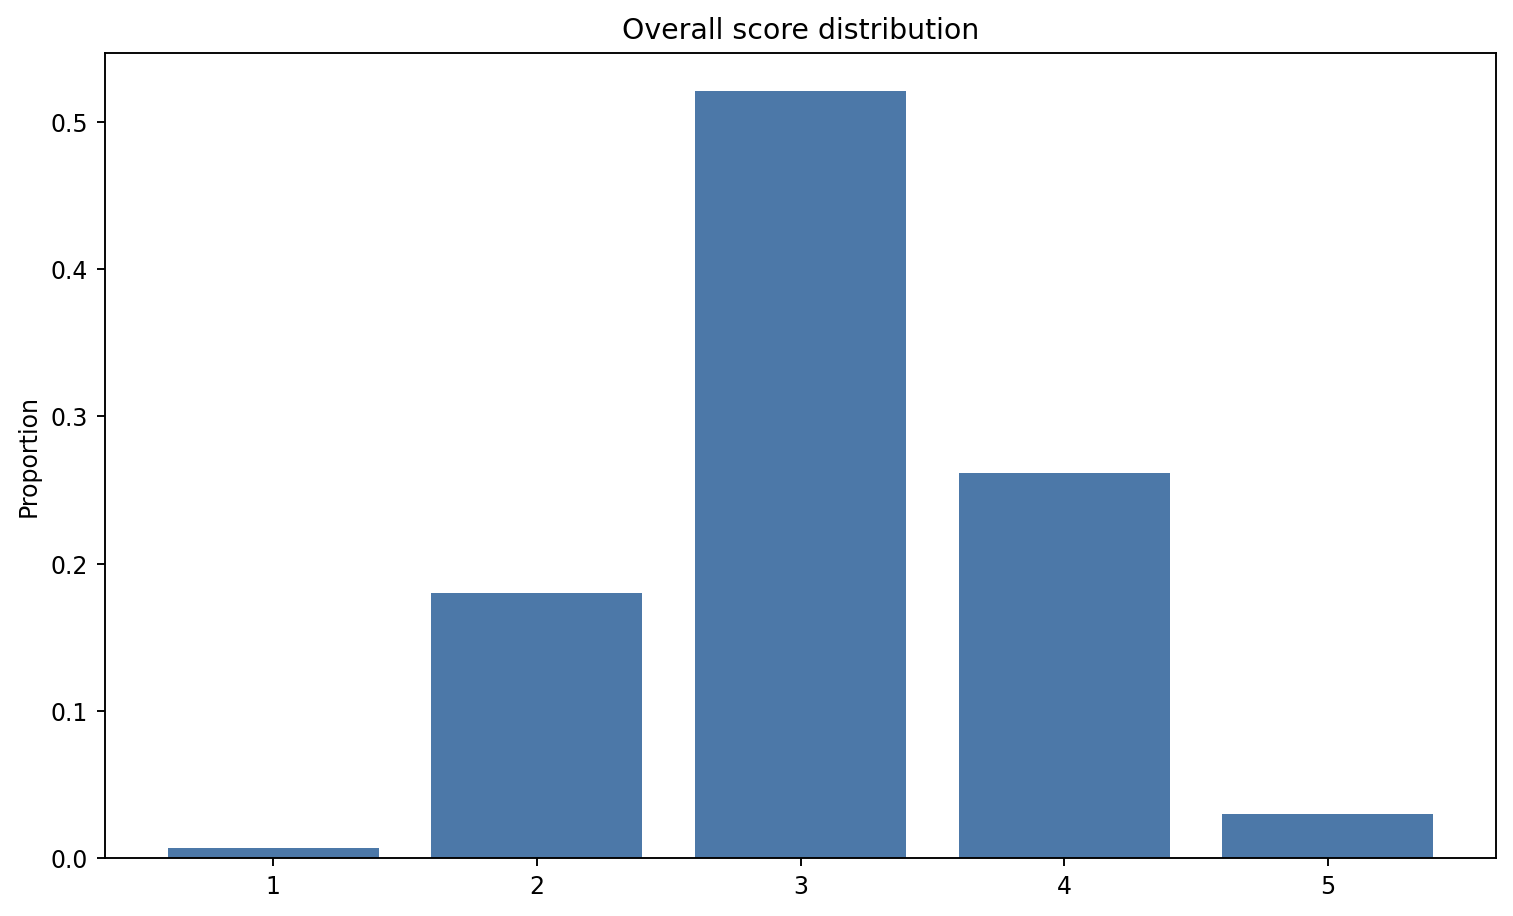

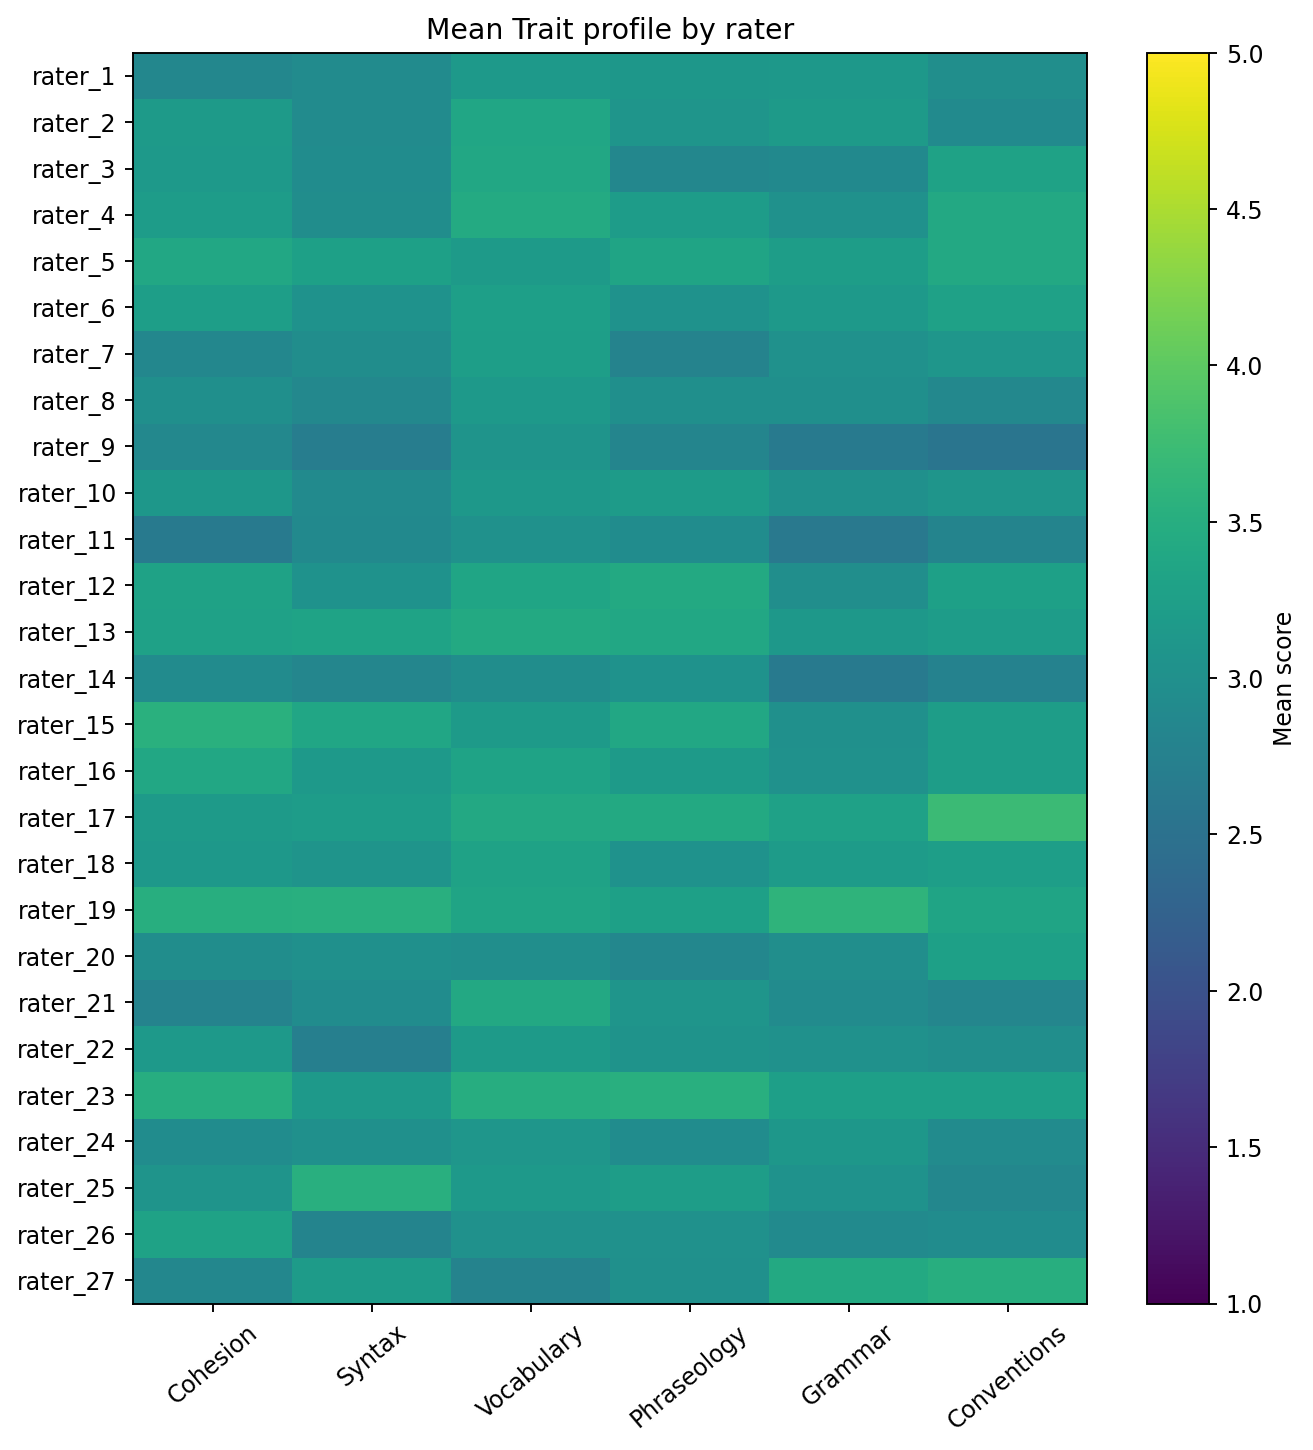

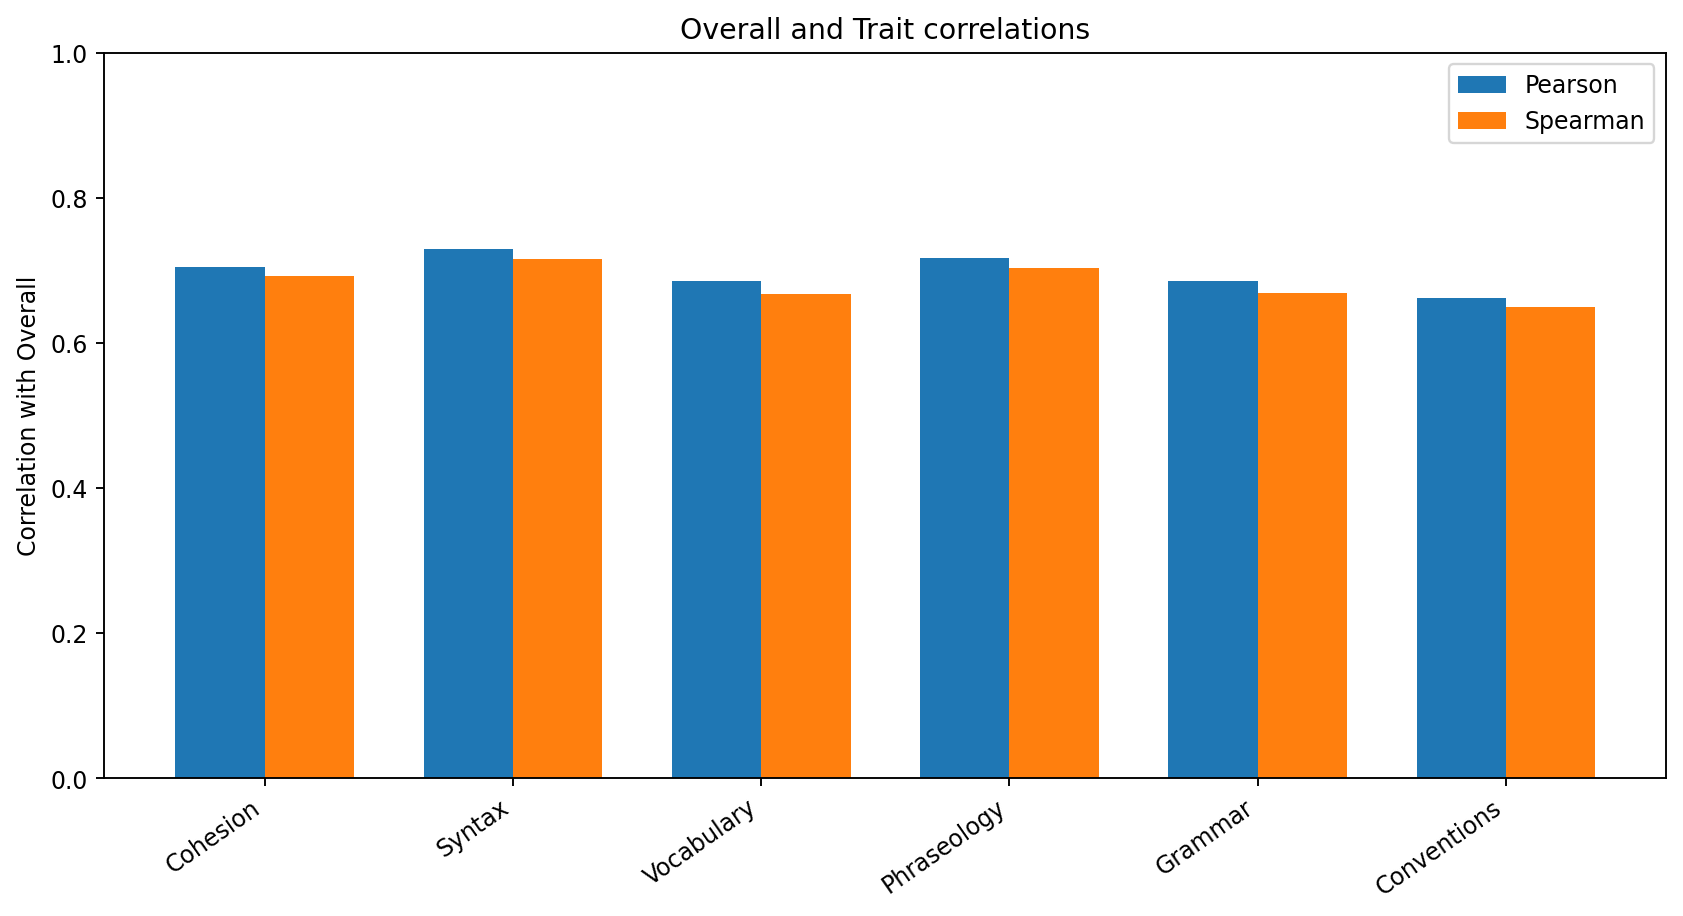

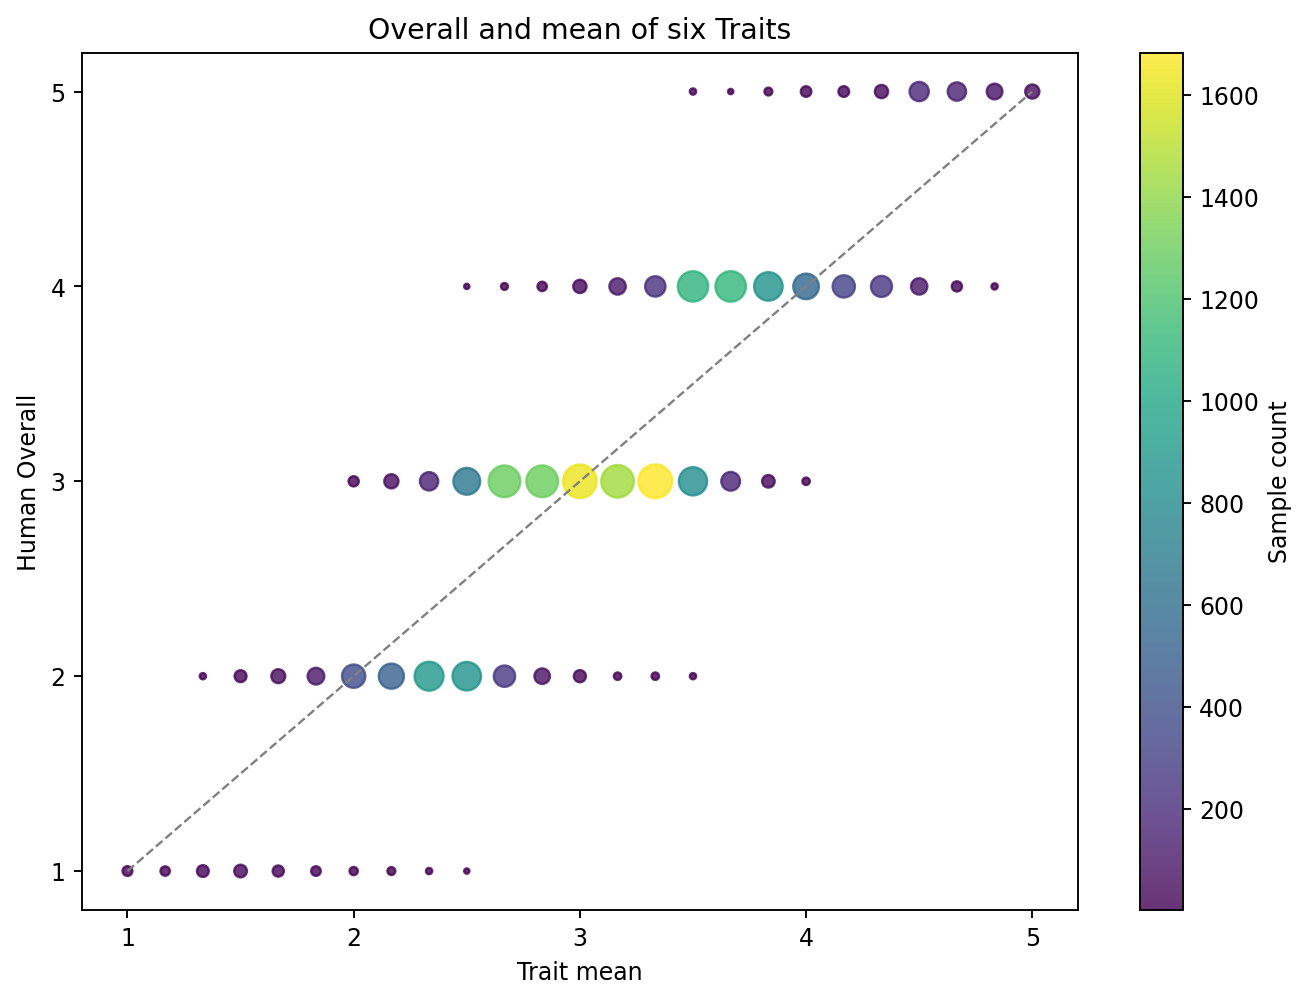

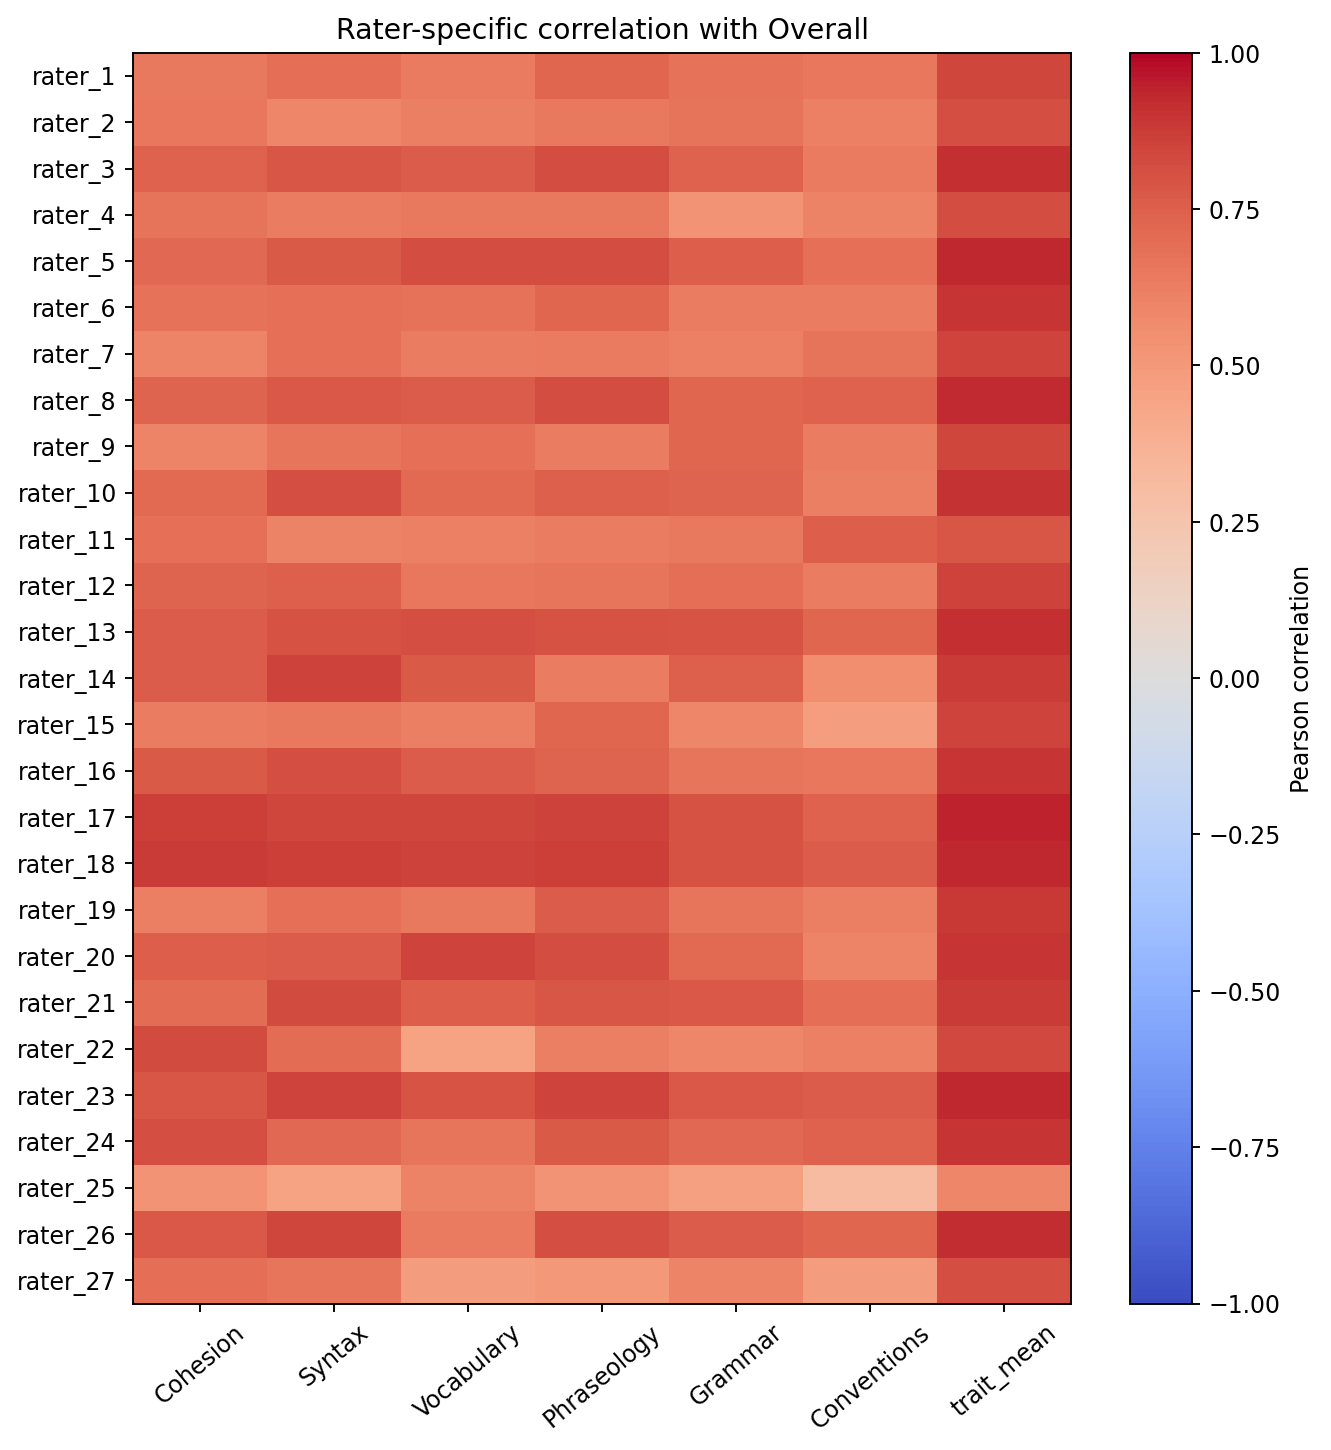

In [8]:
figure_dir = ROOT / 'outputs' / 'basic_analysis' / 'figures'
for name in ['overall_score_distribution.png','rater_trait_profile_heatmap.png',
             'overall_trait_correlations.png','overall_vs_trait_mean.png',
             'rater_overall_trait_correlation_heatmap.png']:
    path = figure_dir / name
    if path.exists(): display(Image(filename=str(path)))

## 8. 解釈上の注意と次段階
採点者平均は答案構成を統制していない未調整の傾向です。相関はTraitの因果的な重みを意味しません。実数値による考察は `docs/basic_analysis_report.md` を参照してください。次段階では、採点者履歴あり・なしの予測比較と、答案構成を統制した統計的検証が必要です。